In [1]:
import torch
import torch.nn as nn
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader, ConcatDataset, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import qmc

from IPython.display import clear_output
import time
from datetime import datetime, timedelta
import gc

np.random.seed(123)
torch.random.manual_seed(123)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [2]:
 # Neural Network
class PINN_Module(nn.Module):

    def __init__(self, model_parameters):
        super(PINN_Module, self).__init__()
        self.Device = model_parameters["Device"]
        self.LowerBounds = model_parameters["LowerBounds"]
        self.UpperBounds = model_parameters["UpperBounds"]
        self.ThermalDiffusivity = model_parameters["ThermalDiffusivity"]
        self.InputDimensions = model_parameters["InputDimensions"]
        self.OutputDimensions = model_parameters["OutputDimensions"]
        self.NumberOfNeurons = model_parameters["NumberOfNeurons"]
        self.NumberOfHiddenLayers = model_parameters["NumberOfHiddenLayers"]
        self.ActivationFunction = model_parameters["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)

        self.init_xavier()


    def forward(self, x):
        lb = self.LowerBounds
        ub = self.UpperBounds
        x = 2*(x - lb)/(ub - lb) - 1
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output


    def init_xavier(self):

        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                # torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)

        self.apply(init_weights)


    def internalEnergyBalanceResidue(self, X, T):

        alpha = self.ThermalDiffusivity

        # Compute the derivatives of the output w.r.t. the inputs (space and time) using AD mechanism:
        diff_T = torch.autograd.grad(T, X, create_graph=True, grad_outputs=torch.ones_like(T))[0]
        Tx, Tt = diff_T[:, 0:1], diff_T[:, 1:2]

        # Compute the second derivative of the output w.r.t. the inputs (only space) using AD mechanism:
        Txx = torch.autograd.grad(Tx, X, create_graph=True, grad_outputs=torch.ones_like(T))[0][:, 0:1]

        residue = Tt - alpha*Txx
        return residue

## Problem data

In [3]:
# Properties of pure solid aluminium
k = 210.0 # W/(m K)
C = 900.0 # J/(kg K)
rho = 2700.0 #kg/m^3
alpha_true = k/(rho*C)

# Boundaries of space and time domains
ti, tf = 0, 1000.0 # s
xi, xf = 0, 1.0 # m

# Non-dimensionalization
nd = True
if nd:
    tf *= alpha_true
    alpha_nd = 1

lb = torch.tensor([xi, ti], device=device)
ub = torch.tensor([xf, tf], device=device)

# Initial and boundary temperatures
T_ref = 100 #100.
bc_value = bc_value_l = bc_value_r = 300.0/T_ref # K
k1 = np.pi/xf
T_ampl = 100.0/T_ref # K
T0 = lambda x: T_ampl*torch.sin(k1*x) + bc_value # K

## Exact solution

In [4]:
# Exact solution
T_exact = lambda x, t: T_ampl*np.sin(k1*x)*np.exp(-k1**2*alpha_nd*t) + bc_value

# Grid for evaluation the exact solution
x_test = np.linspace(xi, xf, 1000)
t_test = np.linspace(ti, tf, 1000)
ms_x, ms_t = np.meshgrid(x_test, t_test)
x_test = np.ravel(ms_x).reshape(-1, 1)
t_test = np.ravel(ms_t).reshape(-1, 1)

T_ex_grid = T_ref * T_exact(x_test, t_test).reshape(ms_x.shape)

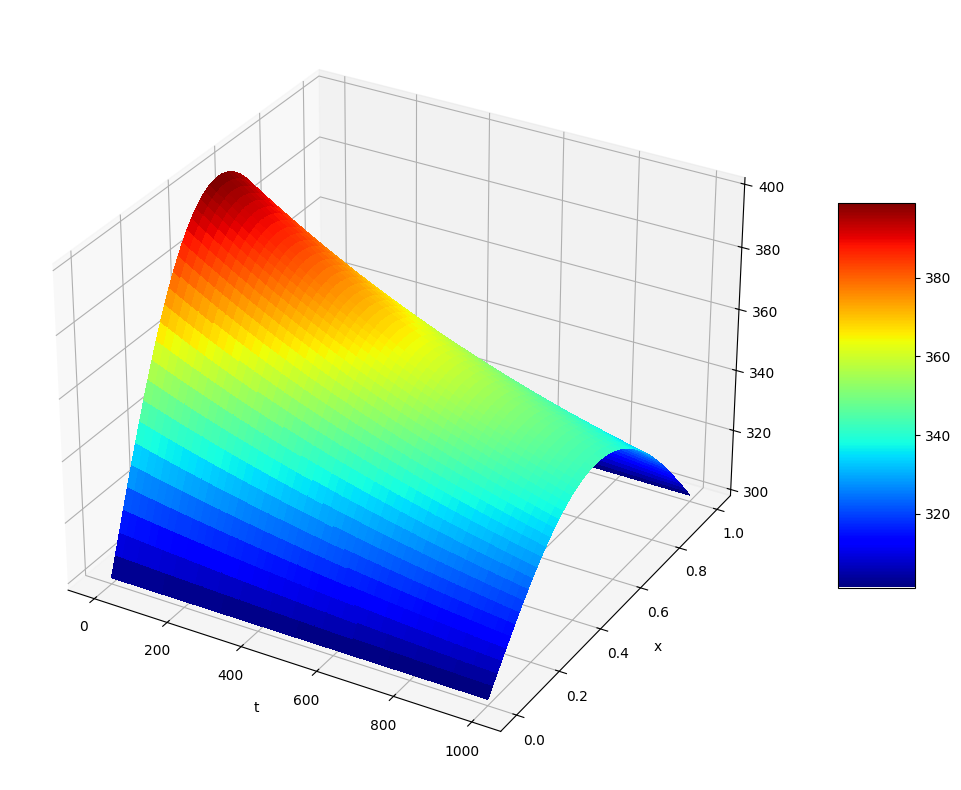

In [5]:
# Plot the exact temperature distribution
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection = '3d')
#ax.view_init(elev=20, azim=-90)
surf1 = ax.plot_surface(ms_t/alpha_true, ms_x, T_ex_grid, cmap=cm.jet, linewidth=0, antialiased=False)
fig.colorbar(surf1, shrink=0.5, aspect=5)
plt.xlabel('t')
plt.ylabel('x')
plt.show()

## Datasets (collocation points and labelled data points)

In [6]:
# Generate equispaced tensors for both space and time domains to pick from
x_tensor = torch.linspace(xi, xf, 10000, device=device)
t_tensor = torch.linspace(ti, tf, 10000, device=device)

# Number of collocation points
N_dom = 1000 # Number of collocation points for evaluating the residuals
N_bc = 300 # Number of collocation points for computing the boundary conditions
N_ic = 500 # Number of collocation points for computing the initial condition
N_data = 1000 # Number of labelled data points

# Train, validation and testing sets
tags = ["Domain", "BoundaryConditions", "InitialCondition"]
isData = True # Flag to indicate whether the analysis would use labelled data or not

# Initialize list of dataset objects
ds = []

In [7]:
## Collocation points for evaluating the residual of the governing PDE

# Generate collocation points within the domain using Latin Hypercube Sampling (LHS) strategy
sampler = qmc.LatinHypercube(d=2, seed=0)
lhs_np = sampler.random(n=N_dom)
lhs_torch = torch.tensor(lhs_np, dtype=torch.float32, device=device)
X_dom = lb + (ub - lb)*lhs_torch
y_dom = torch.zeros((N_dom, 1), device=device)

ds.append(TensorDataset(X_dom, y_dom))

In [8]:
## Collocation points for evaluating the boundary and initial conditions

# Generate random collocation points for the left boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_l = t_tensor[idx_bc].view(-1, 1)
x_bc_l = xi * torch.ones((N_bc, 1), device=device)
X_bc_l = torch.cat([x_bc_l, t_bc_l], axis=1)
y_bc_l = torch.full((N_bc, 1), bc_value_l, device=device)

# Generate random collocation points for the right boundary
idx_bc = np.random.choice(t_tensor.size()[0], N_bc, replace=False)
t_bc_r = t_tensor[idx_bc].view(-1, 1)
x_bc_r = xf * torch.ones((N_bc, 1), device=device)
X_bc_r = torch.cat([x_bc_r, t_bc_r], axis=1)
y_bc_r = torch.full((N_bc, 1), bc_value_r, device=device)

# Concatenate the collocation points of both boundaries
X_bc = torch.cat([X_bc_l, X_bc_r], axis=0)
y_bc = torch.cat([y_bc_l, y_bc_r], axis=0)
ds.append(TensorDataset(X_bc, y_bc))

# Generate collocation points for the initial condition
idx_ic = np.random.choice(x_tensor.size()[0], N_ic, replace=False)
x_ic = x_tensor[idx_ic].view(-1, 1)
t_ic = ti * torch.ones((N_ic, 1), device=device)
X_ic = torch.cat([x_ic, t_ic], axis=1)
y_ic = T0(x_ic)
ds.append(TensorDataset(X_ic, y_ic))

In [9]:
# Generate syntetic temperature labelled data
if isData:
    tags.append("LabelledData")
    omega = 0.01
    sensor_loc = [0.25, 0.5, 0.9]
    x_data, t_data = [], []
    for loc in sensor_loc:
        idx_data = np.random.choice(x_tensor.size()[0], N_data, replace=False)
        x_data.append(torch.full((N_data, 1), loc, device=device))
        t_data.append(t_tensor[idx_data].view(-1, 1))

    X_data = torch.cat([torch.cat(x_data, axis=0), torch.cat(t_data, axis=0)], axis=1)
    exact_temp_data = T_exact(X_data[:, 0].data.cpu().numpy(), X_data[:, 1].data.cpu().numpy())
    noisy_temp_data = exact_temp_data.reshape(-1, 1) + omega*np.max(exact_temp_data)*np.random.normal(size=(len(sensor_loc)*N_data, 1))
    y_data = torch.from_numpy(noisy_temp_data).to(torch.float32).to(device)
    ds.append(TensorDataset(X_data, y_data))


In [10]:
# Dictionary of dataset objects
datasets = dict(zip(tags, ds))

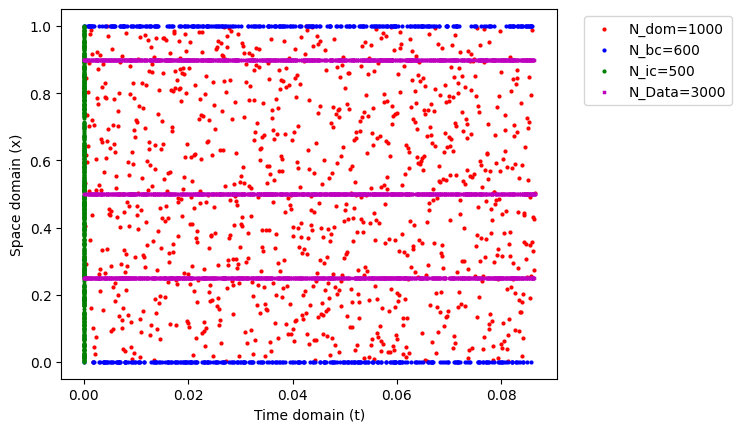

In [11]:
# Plot the locations of the collocation points in the space-time domain
X_dom_train = (datasets["Domain"][:][0]).data.cpu().numpy()
X_bc_train = (datasets["BoundaryConditions"][:][0]).data.cpu().numpy()
X_ic_train = (datasets["InitialCondition"][:][0]).data.cpu().numpy()
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X_dom_train[:, 1:2], X_dom_train[0:, 0:1], s=4, c='r', label=f'N_dom={len(X_dom_train)}')
ax.scatter(X_bc_train[:, 1:2], X_bc_train[:, 0:1], s=4, c='b', label=f'N_bc={len(X_bc_train)}')
ax.scatter(X_ic_train[:, 1:2], X_ic_train[:, 0:1], s=4, c='g', label=f'N_ic={len(X_ic_train)}')
if isData:
    X_data_train = (datasets["LabelledData"][:][0]).data.cpu().numpy()
    y_data_train = (datasets["LabelledData"][:][1]).data.cpu().numpy()
    ax.scatter(X_data_train[:, 1:2], X_data_train[:, 0:1], s=4, c='m', label=f'N_Data={len(X_data_train)}', marker='x')
ax.legend()
plt.xlabel('Time domain (t)')
plt.ylabel('Space domain (x)')
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

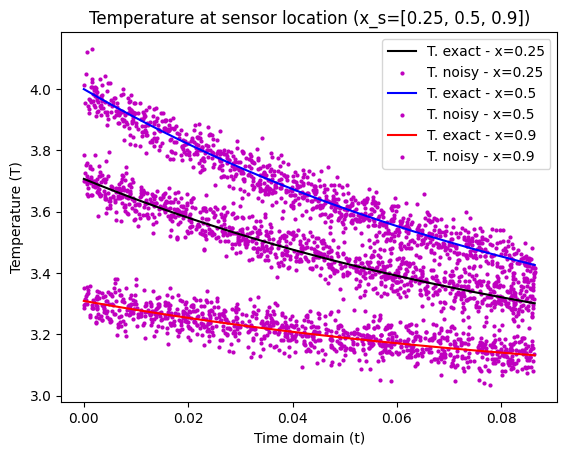

In [12]:
if isData:
    colors = ['k', 'b', 'r', 'g']
    fig = plt.figure()
    ax = fig.add_subplot(111)
    for i, sensor in enumerate(sensor_loc):
        t_data_loc = np.linspace(ti, tf, N_data).reshape(-1, 1)
        x_data_loc = np.full((N_data, 1), sensor)
        T_ex = T_exact(x_data_loc, t_data_loc)
        ax.plot(t_data_loc, T_ex, c=colors[i], label=f'T. exact - x={sensor}')
        ax.scatter(X_data_train[N_data*i:N_data*(i+1), 1:2], y_data_train[N_data*i:N_data*(i+1)], s=4, c='m', label=f'T. noisy - x={sensor}')

    ax.legend()
    plt.xlabel('Time domain (t)')
    plt.ylabel('Temperature (T)')
    plt.title(f'Temperature at sensor location (x_s={sensor_loc})')
    plt.show()

## Main execution - Implementation 1

In [13]:
# Input dictionary for model instance
torch.random.manual_seed(456)
alpha_inv_input = nn.Parameter(torch.rand(1, device=device)) #Make alpha a trainable parameter
tanh = nn.Tanh()
alpha_fun = lambda x: x * tanh(1e3 * x) #torch.exp(x) #x*tanh(1e3*x)
model_parameters = {
    "Device": device,
    "LowerBounds": lb.to(device),
    "UpperBounds": ub.to(device),
    "ThermalDiffusivity": alpha_fun(alpha_inv_input),
    "InputDimensions": 2,
    "OutputDimensions": 1,
    "NumberOfNeurons": 30,
    "NumberOfHiddenLayers": 4,
    "ActivationFunction": nn.Tanh()
}
print('alpha_nd: ', alpha_nd, 'alpha_inv_input: ', alpha_inv_input.item(), 'alpha_inv: ', alpha_fun(alpha_inv_input).item())

alpha_nd:  1 alpha_inv_input:  0.8108147382736206 alpha_inv:  0.8108147382736206


In [14]:
# Model construction
torch.manual_seed(10)
model = PINN_Module(model_parameters).to(device)

In [15]:
# Fitting stage
t0 = datetime.now()
data_time_now = datetime.now().strftime("%d%m%Y_%H%M%S")

epochs = 20000
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam([
    {'params': model.parameters(), 'lr': 1e-3, 'weight_decay': 1e-3},
    {'params': alpha_inv_input, 'lr': 0.1, 'weight_decay': 0.0}
])
loss_train = []
loss_train_dom = []
loss_train_bc = []
loss_train_ic = []
loss_train_data = []
alpha_values = []
train_keys = ['Overall', 'Domain', 'BC', 'IC', 'Data', 'alpha']
for epoch in range(epochs):
    loss_list = []
    optimizer.zero_grad()
    # Move alpha_inv_input to the device within the training loop
    model.ThermalDiffusivity = alpha_fun(alpha_inv_input)
    for tag in tags:
        X = (datasets[tag][:][0]).to(device)
        y = (datasets[tag][:][1]).to(device)
        if tag=='Domain':
            X.requires_grad = True
            T = model(X)
            y_hat = model.internalEnergyBalanceResidue(X, T)
            loss = loss_fn(y_hat, y)
            loss_list.append(loss)

        else:
            T = model(X)
            loss = loss_fn(T, y)
            loss_list.append(loss)

    loss = sum(loss_list)
    if loss < 1e-4:
        print('Overall loss dropped below tolerance value of 1e-4. Training stopped.')
        break
    loss.backward()
    optimizer.step()

    loss_list.insert(0, loss)
    loss_train.append(loss_list[0].item())
    loss_train_dom.append(loss_list[1].item())
    loss_train_bc.append(loss_list[2].item())
    loss_train_ic.append(loss_list[3].item())
    if isData:
        loss_train_data.append(loss_list[4].item())

    alpha_values.append(alpha_inv_input.item())
    loss_list.append(alpha_fun(alpha_inv_input).item()) #loss_list.append(alpha_inv_fun(alpha_inv_input).item())


    if epoch % 100 == 0:
        log_dict = dict(zip(train_keys, loss_list))
        aux = "".join(f"{key}: {value:.5e}, " for key, value in log_dict.items())
        optimizer_str = type(optimizer).__name__
        print(f"##TRAIN## {optimizer_str} - Epoch: {epoch}, " + aux)

elapsed_time_train = datetime.now() - t0
print("\nTraining Time: ", elapsed_time_train.seconds, "[s]")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


##TRAIN## Adam - Epoch: 0, Overall: 9.41174e+02, Domain: 8.97875e+02, BC: 1.08897e+01, IC: 1.90190e+01, Data: 1.33912e+01, alpha: 7.10815e-01, 
##TRAIN## Adam - Epoch: 100, Overall: 2.13720e+01, Domain: 7.23697e-01, BC: 5.21496e+00, IC: 8.27735e+00, Data: 7.15598e+00, alpha: 3.89098e-01, 
##TRAIN## Adam - Epoch: 200, Overall: 6.76556e+00, Domain: 5.08981e-01, BC: 1.34441e+00, IC: 2.76173e+00, Data: 2.15044e+00, alpha: 3.31583e-01, 
##TRAIN## Adam - Epoch: 300, Overall: 1.11908e+00, Domain: 3.26050e-01, BC: 6.51285e-02, IC: 4.79576e-01, Data: 2.48322e-01, alpha: 3.06403e-01, 
##TRAIN## Adam - Epoch: 400, Overall: 3.22348e-01, Domain: 1.67102e-01, BC: 7.54273e-03, IC: 1.19799e-01, Data: 2.79040e-02, alpha: 2.91484e-01, 
##TRAIN## Adam - Epoch: 500, Overall: 2.18687e-01, Domain: 1.03358e-01, BC: 2.50112e-02, IC: 7.43573e-02, Data: 1.59601e-02, alpha: 2.81413e-01, 
##TRAIN## Adam - Epoch: 600, Overall: 1.74904e-01, Domain: 7.18476e-02, BC: 2.58789e-02, IC: 6.27908e-02, Data: 1.43871e-02, a

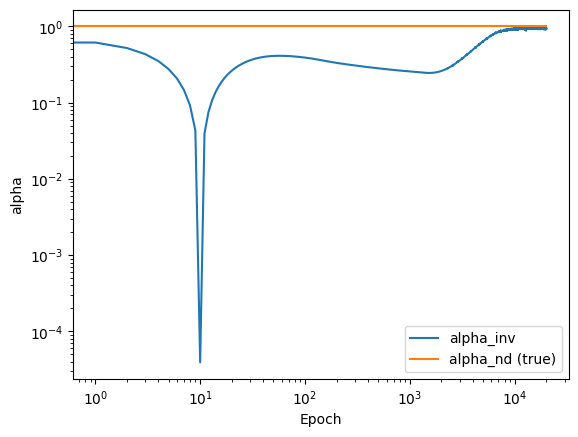

In [16]:
plt.loglog(alpha_fun(torch.tensor(alpha_values)).cpu().detach().numpy())
plt.plot([0, epochs], [alpha_nd, alpha_nd])
plt.xlabel('Epoch')
plt.ylabel('alpha')
plt.legend(['alpha_inv', 'alpha_nd (true)'])
plt.show()

## Loss functions

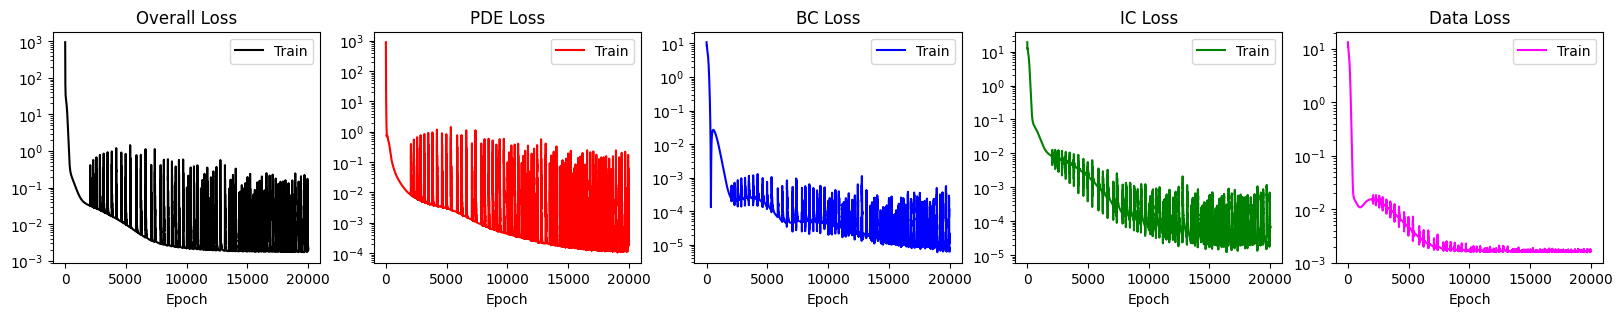

In [17]:
# Evolution of the loss function
loss_train_list = [loss_train, loss_train_dom, loss_train_bc, loss_train_ic]
colors = ['black', 'red', 'blue', 'green']
titles = ['Overall Loss', 'PDE Loss', 'BC Loss', 'IC Loss']
if isData:
    loss_train_list.append(loss_train_data)
    colors.append('magenta')
    titles.append('Data Loss')

fig, ax = plt.subplots(1, len(loss_train_list), figsize=(20, 3))
for i in range(len(loss_train_list)):
    epochs_train = np.arange(0, len(loss_train_list[i]))
    ax[i].semilogy(epochs_train, loss_train_list[i], color=colors[i], label='Train')
    ax[i].set_xlabel('Epoch')
    ax[i].set_title(titles[i])
    ax[i].legend()
plt.show()

## Prediction

In [18]:
# Definition of tensors from the testing points for evaluating the trained PINN
pt_x = torch.from_numpy(x_test).float()
pt_t = torch.from_numpy(t_test).float()
ms_Tex = T_ref*T_exact(x_test, t_test).reshape(ms_x.shape)

In [19]:
# Predicted solution
X_pred = torch.cat([pt_x, pt_t], axis=1).to(device)
Tpred = model(X_pred).data.cpu().numpy()
ms_Tpred = T_ref*Tpred.reshape(ms_x.shape)

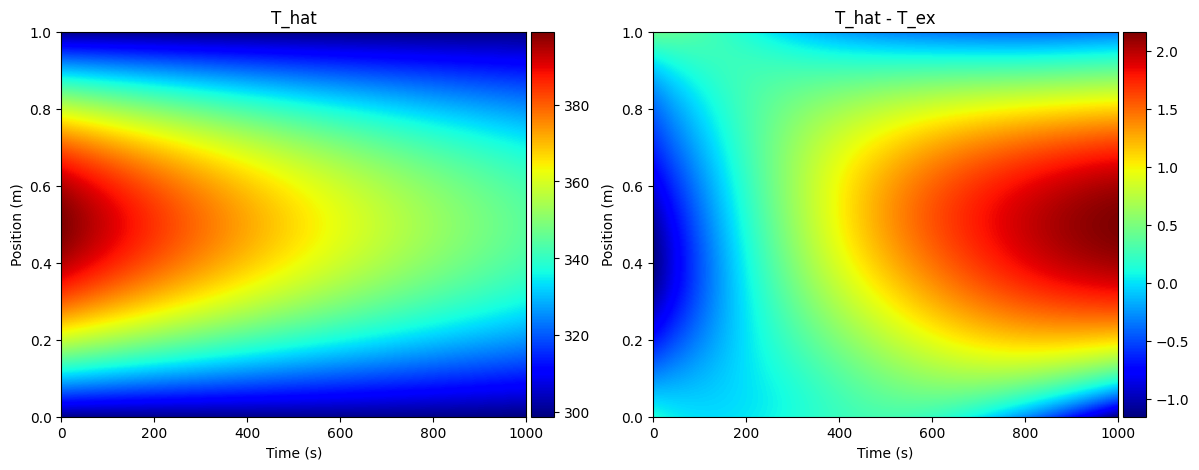

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ax = axs[0]
h = ax.imshow(ms_Tpred.T, interpolation='nearest', cmap='jet',
              extent=[ti, tf/alpha_true, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat')

ax = axs[1]
h = ax.imshow((ms_Tpred-ms_Tex).T, interpolation='nearest', cmap='jet',
              extent=[ti, tf/alpha_true, xi, xf],
              origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(h, cax=cax, shrink=0.5, aspect=10)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (m)')
ax.set_title('T_hat - T_ex')

plt.show()

In [24]:
import copy

# ---------------------------------------------------------
# Sensibilidad numerica por diferencias finitas "fisicas":
# se resuelve el forward (solo fisica, alpha fijo) en alpha_hat +- d_alpha,
# partiendo de los pesos ya convergidos, y se diferencia.
# ---------------------------------------------------------

alpha_hat = alpha_fun(alpha_inv_input).item()
d_alpha = 0.01 * alpha_hat     # 1% de alpha_hat; ajustar si hace falta (ver nota abajo)

def clone_and_freeze_alpha(base_model, alpha_fijo):
    m = copy.deepcopy(base_model)
    m.ThermalDiffusivity = torch.tensor([alpha_fijo], device=device)  # fijo, NO requiere grad
    return m

model.ThermalDiffusivity = model.ThermalDiffusivity.detach()
model_plus  = clone_and_freeze_alpha(model, alpha_hat + d_alpha)
model_minus = clone_and_freeze_alpha(model, alpha_hat - d_alpha)

def refit_physics_only(m, n_epochs=2000, lr=1e-4):
    opt = torch.optim.Adam(m.parameters(), lr=lr)   # SOLO pesos de la red, alpha ya fijo
    for epoch in range(n_epochs):
        opt.zero_grad()
        loss_total = 0.0
        for tag in ['Domain', 'BoundaryConditions', 'InitialCondition']:           # <-- SIN 'Data': no re-identificamos nada
            X = (datasets[tag][:][0]).to(device)
            y = (datasets[tag][:][1]).to(device)
            if tag == 'Domain':
                X.requires_grad = True
                T = m(X)
                y_hat = m.internalEnergyBalanceResidue(X, T)
            else:
                y_hat = m(X)
            loss_total = loss_total + torch.mean((y_hat - y)**2)
        loss_total.backward()
        opt.step()
    return m

model_plus  = refit_physics_only(model_plus)
model_minus = refit_physics_only(model_minus)

# Sensibilidad por diferencia central (mas precisa que forward/backward)
with torch.no_grad():
    T_plus  = model_plus(X_data)
    T_minus = model_minus(X_data)
    S = ((T_plus - T_minus) / (2*d_alpha)).squeeze().cpu().numpy()

sigma = omega * np.max(exact_temp_data)
I_alpha = np.sum(S**2) / sigma**2
var_alpha_min = 1.0 / I_alpha
print(f"I(alpha_hat) numerico = {I_alpha:.4e}")
print(f"sigma(alpha_hat) min  = {np.sqrt(var_alpha_min):.4e}")

I(alpha_hat) numerico = 8.6044e+04
sigma(alpha_hat) min  = 3.4091e-03


In [25]:
x_sensores = X_data[:, 0].detach().cpu().numpy()

print(f"{'sensor x_s':>10} | {'I_k(alpha)':>14} | {'% del total':>10} | {'sigma_k min':>12}")
I_total = 0.0
resultados = {}
for xs in sensor_loc:
    mask = np.isclose(x_sensores, xs)          # filas de X_data que corresponden a este sensor
    I_k = np.sum(S[mask]**2) / sigma**2
    resultados[xs] = I_k
    I_total += I_k

for xs, I_k in resultados.items():
    print(f"{xs:10.2f} | {I_k:14.4e} | {100*I_k/I_total:10.1f} | {np.sqrt(1/I_k):12.4e}")

print(f"\nI(alpha) total = {I_total:.4e}  (debe coincidir con I_alpha calculado antes)")

sensor x_s |     I_k(alpha) | % del total |  sigma_k min
      0.25 |     2.7400e+04 |       31.8 |   6.0412e-03
      0.50 |     5.3242e+04 |       61.9 |   4.3338e-03
      0.90 |     5.4014e+03 |        6.3 |   1.3606e-02

I(alpha) total = 8.6044e+04  (debe coincidir con I_alpha calculado antes)
